In [1]:
from helper import *

In [2]:
# load data
df = pd.read_csv(ROOT + 'train.csv')

# check for duplicates
print('Number of duplicates:', df.duplicated().sum())

# show a row
df.sample()

Number of duplicates: 0


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
4120,4399_01,Earth,False,G/724/P,TRAPPIST-1e,25.0,False,141.0,3.0,640.0,0.0,100.0,All Wolferton,False


- "PassengerId" is the unique identifier column.
- "Transported" is the label.
- "Name" also seems to be a unique identifier.
- "Cabin" seems to contain three seperate values split by slashes. I will split  into 3 new columns.

In [3]:
# split Cabin into 3 new columns
df[['Cabin1', 'Cabin2', 'Cabin3']] = df['Cabin'].str.split('/', expand=True)

# drop old Cabin col, room number, and Name
df = df.drop(columns=['Cabin', 'Cabin2', 'Name'])

# check
df.sample()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin1,Cabin3
2665,2858_01,Europa,True,TRAPPIST-1e,36.0,False,0.0,0.0,0.0,0.0,0.0,True,C,S


In [4]:
# look at unique values
show_unique_vals(df)

"PassengerId" has 8693 unique values

"HomePlanet" has 3 unique values
['Europa' 'Earth' 'Mars' nan]

"CryoSleep" has 2 unique values
[False True nan]

"Destination" has 3 unique values
['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e' nan]

"Age" has 80 unique values

"VIP" has 2 unique values
[False True nan]

"RoomService" has 1273 unique values

"FoodCourt" has 1507 unique values

"ShoppingMall" has 1115 unique values

"Spa" has 1327 unique values

"VRDeck" has 1306 unique values

"Transported" has 2 unique values
[False  True]

"Cabin1" has 8 unique values
['B' 'F' 'A' 'G' nan 'E' 'D' 'C' 'T']

"Cabin3" has 2 unique values
['P' 'S' nan]



In [5]:
# check for nulls
show_shape_and_nulls(df)

Shape: (8693, 14)
Null values:


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin1,Cabin3
0,0,201,217,182,179,203,181,183,208,183,188,0,199,199


- Roughly 200 nulls in each of the non ID/Label columns.
- The categorical column nulls can be filled with "Unknown", and I will manually inspect the numerical columns to find the best way to fill them.

# Fill Nulls

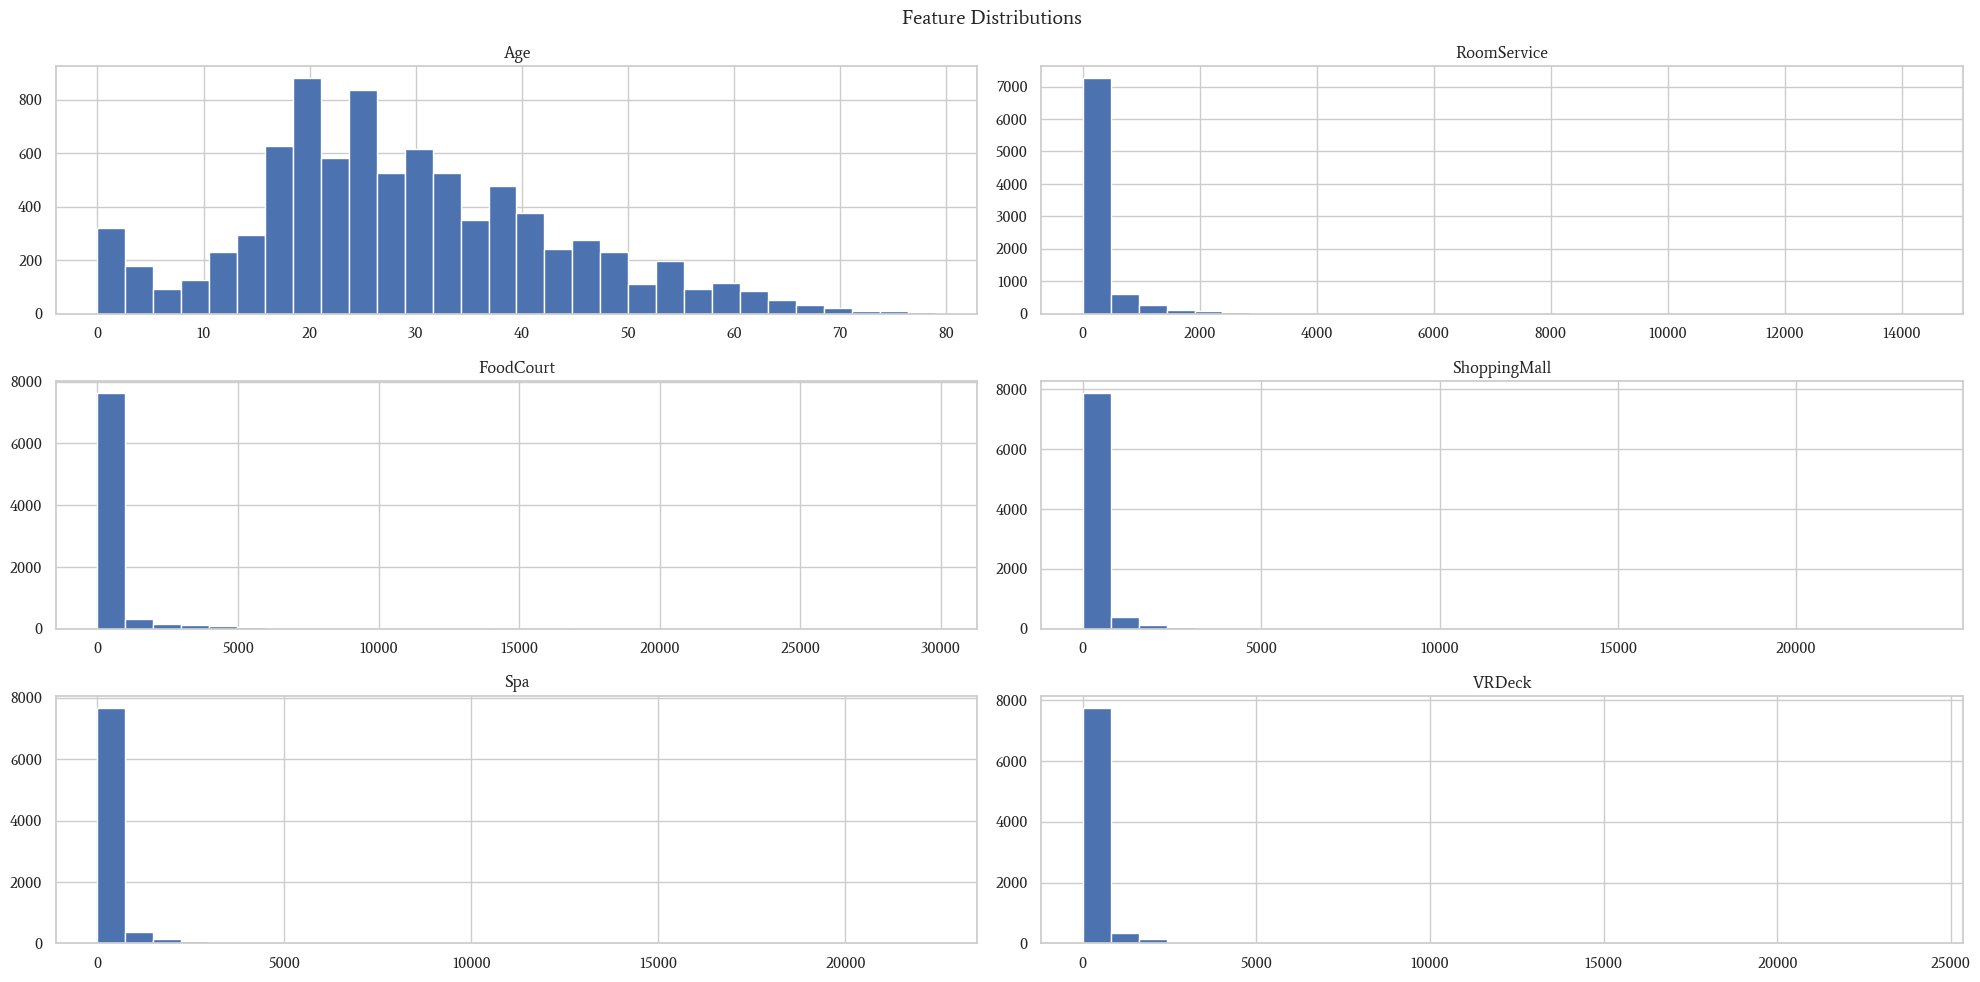

In [6]:
# plot histograms for all numerical features (check for normality)
df.hist(bins=30, figsize=(20, 10))
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

- The Age col is relatively normal. We will fill with the median here.
- Most values for the 5 expense columns are 0. Thus, filling with 0 is reasonable.

In [7]:
# fill Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# define nmonetary cols
expenses_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# check percent of rows where all 5 expense cols were 0 or null
print(f'Percent of rows where all 5 expense cols were $0: {(df[expenses_cols] == 0).all(axis=1).mean()*100:.1f}%')
print(f'Percent of rows where all 5 expense cols were null: {(df[expenses_cols].isnull()).all(axis=1).mean()*100:.1f}%')

Percent of rows where all 5 expense cols were $0: 37.4%
Percent of rows where all 5 expense cols were null: 0.0%


- Over one-third of passengers spent 0 on the spaceship. This further verifies that filling with $0 is acceptable.

In [8]:
# fill 5 expense cols with 0
df[expenses_cols] = df[expenses_cols].fillna(0)

# set CryoSleep and VIP True and False to 'T' and 'F'
df['CryoSleep'] = df['CryoSleep'].replace({True: 'T', False: 'F'})
df['VIP'] = df['VIP'].replace({True: 'T', False: 'F'})

# fill non-numeric cols with 'Unknown'
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].fillna('Unknown')

# check nulls
show_shape_and_nulls(df)

Shape: (8693, 14)
Null values:


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin1,Cabin3
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# Feature Engineering

In [40]:
# show average spending for VIPs
df.query('VIP == "T"')[expenses_cols].mean()

RoomService      464.095477
FoodCourt       1756.778894
ShoppingMall     241.502513
Spa              753.065327
VRDeck          1210.035176
dtype: float64

In [41]:
# show average spending for non-VIPs
df.query('VIP == "F"')[expenses_cols].mean()

RoomService     212.686045
FoodCourt       417.440598
ShoppingMall    169.702931
Spa             295.197202
VRDeck          276.477868
dtype: float64

In [42]:
# Unkonwn VIPs
df.query('VIP == "Unknown"')[expenses_cols].mean()

RoomService     279.832512
FoodCourt       431.714286
ShoppingMall     93.724138
Spa             248.527094
VRDeck          294.162562
dtype: float64

In [9]:
# create total_expense column
df['TotalExpense'] = df[expenses_cols].sum(axis=1)

# check
df.sample()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin1,Cabin3,TotalExpense
1559,1655_01,Earth,F,TRAPPIST-1e,28.0,F,3202.0,0.0,0.0,0.0,5.0,False,Unknown,Unknown,3207.0


In [11]:
# create multiple feature sets
feature_sets = create_feature_sets(df)

# view feature sets
feature_sets.keys()

dict_keys(['base_features', 'poly_features', 'poly_doubled_features', 'interaction_features', 'poly_interaction_features'])

- feature_sets is a dictionary that contains  unique feature sets.

# Test Models

In [44]:
# define models and scalers
models = [LogisticRegression(n_jobs=-1, random_state=SEED), RandomForestClassifier(n_jobs=-1, random_state=SEED), XGBClassifier(n_jobs=-1, random_state=SEED)]
scalers = [StandardScaler(), MinMaxScaler(), RobustScaler()]

# create a df to hold model performance
models_df = pd.DataFrame(columns=['Model', 'Model_Params', 'Scaler', 'Feature_Set', 'Train_LogLoss', 'Val_LogLoss', 'Train_Acc', 'Val_Acc']).astype({
    'Model': 'object', 'Model_Params': 'object', 'Scaler': 'object', 'Feature_Set': 'object', 'Train_LogLoss': 'float', 'Val_LogLoss': 'float', 'Train_Acc': 'float', 'Val_Acc': 'float'})
models_df

,Model,Model_Params,Scaler,Feature_Set,Train_LogLoss,Val_LogLoss,Train_Acc,Val_Acc


In [46]:
# run models
for model in tqdm(models, desc="Running Models"):
    for name, data in feature_sets.items():
        for scaler in scalers:
            cross_val_model(estimator=model, data_name=name, data=data, scaler=scaler, models_df=models_df)

Running Models: 100%|██████████| 3/3 [04:27<00:00, 89.29s/it]


In [49]:
# inspect
models_df.sort_values(by='Val_LogLoss').head()

,Model,Model_Params,Scaler,Feature_Set,Train_LogLoss,Val_LogLoss,Train_Acc,Val_Acc
34,XGBClassifier,"{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 9, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}",MinMaxScaler,poly_features,3.142883,7.243543,0.912803,0.799034
33,XGBClassifier,"{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 9, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}",StandardScaler,poly_features,3.142883,7.243543,0.912803,0.799034
41,XGBClassifier,"{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 9, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}",RobustScaler,interaction_features,3.142883,7.243543,0.912803,0.799034
40,XGBClassifier,"{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 9, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}",MinMaxScaler,interaction_features,3.142883,7.243543,0.912803,0.

- XGBoost seemed to do the best on the poly_features. Now, we'll hypertune a model.

# Hyperparameter Search

In [36]:
# define X and y
X = feature_sets['poly_features'].drop(columns=['PassengerId', 'Transported'])
y = df['Transported']

In [ ]:
# define the parameter search space
param_bounds = {
    'max_depth': (3, 20),
    'n_estimators': (100, 1000),
    'learning_rate': (0.001, 0.1),
    'gamma': (0, 0.5),
    'min_child_weight': (1, 10),
    'subsample': (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
    'colsample_bylevel': (0.5, 1.0),
    'colsample_bynode': (0.5, 1.0)
}

# run bayesian optimization
optimizer = BayesianOptimization(f=lambda max_depth, learning_rate, gamma, min_child_weight, subsample,
            colsample_bytree, colsample_bylevel, colsample_bynode: 
            xgb_cv(max_depth, learning_rate, gamma, min_child_weight, subsample,
                   colsample_bytree, colsample_bylevel, colsample_bynode, X, y)
    pbounds=param_bounds,
    random_state=SEED,
    verbose=2
)

# optimize for 110 iterations
optimizer.maximize(init_points=10, n_iter=100)

|   iter    |  target   | colsam... | colsam... | colsam... |   gamma   | learni... | max_depth | min_ch... | n_esti... | subsample |
-------------------------------------------------------------------------------------------------------------------------------------
| 1         | -0.407    | 0.6873    | 0.9754    | 0.866     | 0.2993    | 0.01645   | 5.652     | 1.523     | 879.6     | 0.8006    |
| 2         | -0.4068   | 0.854     | 0.5103    | 0.985     | 0.4162    | 0.02202   | 6.091     | 2.651     | 373.8     | 0.7624    |
| 3         | -0.427    | 0.716     | 0.6456    | 0.8059    | 0.06975   | 0.02992   | 9.228     | 5.105     | 806.7     | 0.5998    |
| 4         | -0.4116   | 0.7571    | 0.7962    | 0.5232    | 0.3038    | 0.01788   | 4.106     | 9.54      | 969.1     | 0.9042    |
| 5         | -0.4226   | 0.6523    | 0.5488    | 0.8421    | 0.2201    | 0.01308   | 11.42     | 1.309     | 918.4     | 0.6294    |
| 6         | -0.4278   | 0.8313    | 0.6559    | 0.76      | 

- After training 110 XGBoost models, we found a winner. And it came on our second iteration... You have to love machine learning.

In [ ]:
# save best params for xgb
best_params = {'colsample_bylevel': 0.8540362888980227,
 'colsample_bynode': 0.5102922471479012,
 'colsample_bytree': 0.9849549260809971,
 'gamma': 0.41622132040021087,
 'learning_rate': 0.022021571957149343,
 'max_depth': 6,
 'min_child_weight': 2.650640588680904,
 'n_estimators': 373,
 'subsample': 0.762378215816119,
 'objective': 'binary:logistic',
 'eval_metric': 'logloss',
 'use_label_encoder': False,
 'tree_method': 'hist',
 'random_state': 42}

In [41]:
# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# train final model with best parameters
pipeline = make_pipeline(XGBClassifier(**best_params), StandardScaler())
pipeline.fit(X_train, y_train)

# evaluate on test data
test_acc = pipeline.score(X_test, y_test)
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.7947


- Final test set accuracy of 79.47%.

# Format Test Data

In [17]:
# apply these transformations to test data
test = pd.read_csv('data/test.csv')

# add new cabin cols, drop old cabin col
test[['Cabin1', 'Cabin2', 'Cabin3']] = test['Cabin'].str.split('/', expand=True)
test = test.drop(columns=['Cabin', 'Cabin2', 'Name'])

# check for nulls
show_shape_and_nulls(test)

Shape: (4277, 13)
Null values:


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Cabin1,Cabin3
0,0,87,93,92,91,93,82,106,98,101,80,100,100


In [19]:
# fill Age with median
test['Age'] = test['Age'].fillna(test['Age'].median())

# fill 5 expense cols with 0
test[expenses_cols] = test[expenses_cols].fillna(0)

# set CryoSleep and VIP True and False to 'T' and 'F'
test['CryoSleep'] = test['CryoSleep'].replace({True: 'T', False: 'F'})
test['VIP'] = test['VIP'].replace({True: 'T', False: 'F'})

# fill non-numeric cols with 'Unknown'
str_cols = test.select_dtypes(include='object').columns
test[str_cols] = test[str_cols].fillna('Unknown')

# create total_expense column
test['TotalExpense'] = test[expenses_cols].sum(axis=1)

# check nulls
show_shape_and_nulls(df)

Shape: (8693, 15)
Null values:


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin1,Cabin3,TotalExpense
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# Final Predictions

In [23]:
# define X and y
X = feature_sets['poly_features'].drop(columns=['PassengerId', 'Transported'])
y = df['Transported']

# train on entire dataset
pipeline = make_pipeline(XGBClassifier(**best_params), StandardScaler())
pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000026F51753590>)])),
                ('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               co...
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.022021571957149343, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=6,
                               max_leaves=None,
                               min_child_weight=2.650640588680904, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=373, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [42]:
# num_cols
num_cols = test.select_dtypes(include='number').columns

# create polynomial features for test set
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
poly_features = poly.fit_transform(test[num_cols])
poly_df = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(num_cols))
poly_df.index = test.index
poly_test = pd.concat([test.drop(num_cols, axis=1), poly_df], axis=1)

# define X and y
X = poly_test.drop(columns=['PassengerId'])

# make predictions and cast to bool
predictions = pipeline.predict(X).astype(bool)

# create submission df with 'PassengerId' and 'Transported' columns
submission = pd.DataFrame({'PassengerId': test['PassengerId'], 'Transported': predictions})

# check
submission.sample()

,PassengerId,Transported
3044,6682_01,True


In [35]:
# save submission
submission.to_csv('data/submission.csv', index=False)